In [ ]:
import open3d as o3d

pcd = o3d.io.read_point_cloud("gaussians/single/chair_webots.ply")

print("Has points:", pcd.has_points())
print("Has colors:", pcd.has_colors())
print("Has normals:", pcd.has_normals())


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Has points: True
Has colors: False
Has normals: True


In [ ]:
import os
import numpy as np
import torch
from plyfile import PlyData
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
ply_path = "gaussians/single/chair_webots.ply"  

assert os.path.exists(ply_path), f"PLY file not found: {ply_path}"

plydata = PlyData.read(ply_path)
vertex_el = plydata.elements[0]

print("Number of points:", len(vertex_el))
print("Available vertex properties:")
for prop in vertex_el.properties:
    print(f"  - {prop.name} (dtype={prop.dtype})")

Number of points: 140640
Available vertex properties:
  - x (dtype=<bound method PlyProperty.dtype of PlyProperty('x', 'float')>)
  - y (dtype=<bound method PlyProperty.dtype of PlyProperty('y', 'float')>)
  - z (dtype=<bound method PlyProperty.dtype of PlyProperty('z', 'float')>)
  - nx (dtype=<bound method PlyProperty.dtype of PlyProperty('nx', 'float')>)
  - ny (dtype=<bound method PlyProperty.dtype of PlyProperty('ny', 'float')>)
  - nz (dtype=<bound method PlyProperty.dtype of PlyProperty('nz', 'float')>)
  - f_dc_0 (dtype=<bound method PlyProperty.dtype of PlyProperty('f_dc_0', 'float')>)
  - f_dc_1 (dtype=<bound method PlyProperty.dtype of PlyProperty('f_dc_1', 'float')>)
  - f_dc_2 (dtype=<bound method PlyProperty.dtype of PlyProperty('f_dc_2', 'float')>)
  - opacity (dtype=<bound method PlyProperty.dtype of PlyProperty('opacity', 'float')>)
  - scale_0 (dtype=<bound method PlyProperty.dtype of PlyProperty('scale_0', 'float')>)
  - scale_1 (dtype=<bound method PlyProperty.dtype

In [ ]:
# Positions
xyz = np.stack(
    [
        np.asarray(vertex_el["x"]),
        np.asarray(vertex_el["y"]),
        np.asarray(vertex_el["z"]),
    ],
    axis=1,
)  # (N, 3)

# DC spherical-harmonic color coefficients
f_dc_0 = np.asarray(vertex_el["f_dc_0"])  # R-like
f_dc_1 = np.asarray(vertex_el["f_dc_1"])  # G-like
f_dc_2 = np.asarray(vertex_el["f_dc_2"])  # B-like

colors_dc = np.stack([f_dc_0, f_dc_1, f_dc_2], axis=1)  # (N, 3)

print("xyz shape:", xyz.shape)
print("colors_dc shape:", colors_dc.shape)
print("First 5 xyz rows:\n", xyz[:5])
print("\nFirst 5 DC color rows (f_dc_0/1/2):\n", colors_dc[:5])

xyz shape: (140640, 3)
colors_dc shape: (140640, 3)
First 5 xyz rows:
 [[-0.23819143 -0.28377187  0.02377993]
 [-0.23731536 -0.28284746  0.02110946]
 [-0.23818293 -0.28334847  0.01924956]
 [-0.23741028 -0.28300473  0.0231303 ]
 [-0.23790902 -0.28315556  0.01837862]]

First 5 DC color rows (f_dc_0/1/2):
 [[ 1.2627103   0.79694945  0.61275953]
 [ 0.72009116  0.37324196 -0.4414509 ]
 [ 0.78791404  0.40447298 -0.13278455]
 [ 0.9346341   0.52317584  0.20157436]
 [ 0.81432945  0.42782137 -0.29614663]]


In [3]:
import numpy as np
# Rough RGB approximation from DC term (similar to renderer's shift + clamp)
rgb_approx = np.clip(colors_dc + 0.5, 0.0, 1.0)

print("RGB approx min per channel:", rgb_approx.min(axis=0))
print("RGB approx max per channel:", rgb_approx.max(axis=0))


NameError: name 'colors_dc' is not defined

RGB approx min per channel: [0. 0. 0.]
RGB approx max per channel: [1. 1. 1.]


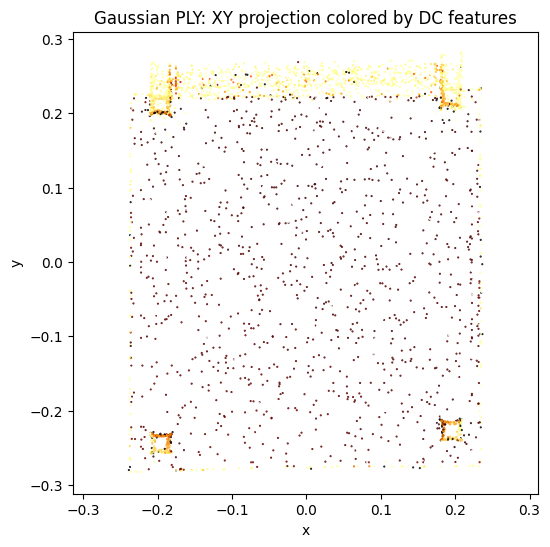

: 

In [ ]:

# Visualize a random subset in XY plane, colored by RGB
num_plot = min(5000, xyz.shape[0])
idx = np.random.choice(xyz.shape[0], size=num_plot, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(
    xyz[idx, 0],
    xyz[idx, 1],
    c=rgb_approx[idx],
    s=1,
    marker=".",
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian PLY: XY projection colored by DC features")
plt.axis("equal")
plt.show()

In [ ]:
import open3d as o3d

# Reload the same PLY as a point cloud (or reuse your existing `pcd`)
pcd = o3d.io.read_point_cloud("gaussians/single/chair_webots.ply")

# `rgb_approx` is (N, 3) in [0, 1] and has same length as `pcd.points`
pcd.colors = o3d.utility.Vector3dVector(rgb_approx.astype(np.float64))

print("Has points:", pcd.has_points())
print("Has colors:", pcd.has_colors())

o3d.visualization.draw_geometries([pcd])

In [ ]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz.astype(np.float64))
pcd.colors = o3d.utility.Vector3dVector(rgb_approx.astype(np.float64))

o3d.visualization.draw_geometries([pcd])